In [ ]:
from pathlib import Path

import duckdb as db
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Detect project root robustly.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

PARQUET_PATH = PROCESSED_DIR / "crimes_clean_dedup_all_years.parquet"
PARQUET_SQL_PATH = PARQUET_PATH.as_posix()

# true to output the figures
EXPORT_OUTPUTS = False

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Crime parquet path: {PARQUET_PATH}")
print(f"Parquet exists: {PARQUET_PATH.exists()}")

if not PARQUET_PATH.exists():
    raise FileNotFoundError(
        "Could not find crimes_clean_dedup_all_years.parquet. "
        "Expected it under data/processed/."
    )


Project root: c:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20
Crime parquet path: c:\Users\Alejandro\Desktop\Uni Files\cbl_crime\cbl_20\data\processed\crimes_clean_dedup_all_years.parquet
Parquet exists: True


In [2]:
def save_table(df: pd.DataFrame, filename: str) -> None:
    """Save a table to outputs/tables when EXPORT_OUTPUTS is True."""
    if EXPORT_OUTPUTS:
        df.to_csv(TABLES_DIR / filename, index=False)


def save_figure(filename: str) -> None:
    """Save the current matplotlib figure to outputs/figures when EXPORT_OUTPUTS is True."""
    if EXPORT_OUTPUTS:
        plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")


In [3]:
# Table: first rows / schema sanity check
sample_rows = db.sql(f"""
    SELECT *
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
    LIMIT 5
""").df()

sample_rows


,Month,Falls within,Longitude,Latitude,LSOA code,LSOA name,Crime type
0,2013-05,Derbyshire Constabulary,-1.359885,53.014737,E01019438,Amber Valley 012C,Shoplifting
1,2013-05,Derbyshire Constabulary,-1.486916,52.981598,E01019426,Amber Valley 016B,Burglary
2,2013-05,Derbyshire Constabulary,-1.591089,52.941784,E01019472,Amber Valley 016D,Anti-social behaviour
3,2013-05,Derbyshire Constabulary,-1.353828,53.005095,E01019437,Amber Valley 017A,Criminal damage and arson
4,2013-05,Derbyshire Constabulary,-1.340087,53.022782,E01019452,Amber Valley 017C,Criminal damage and arson


In [4]:
# Table: column names and dtypes from DuckDB
schema_table = db.sql(f"""
    DESCRIBE SELECT *
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
""").df()

schema_table


,column_name,column_type,null,key,default,extra
0,Month,VARCHAR,YES,None,None,None
1,Falls within,VARCHAR,YES,None,None,None
2,Longitude,VARCHAR,YES,None,None,None
3,Latitude,VARCHAR,YES,None,None,None
4,LSOA code,VARCHAR,YES,None,None,None
5,LSOA name,VARCHAR,YES,None,None,None
6,Crime type,VARCHAR,YES,None,None,None


In [5]:
# Table: minimum and maximum month
month_range = db.sql(f"""
    SELECT
        MIN("Month") AS min_month,
        MAX("Month") AS max_month
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
""").df()

month_range


,min_month,max_month
0,2010-12,2026-03


In [6]:
# Table: total crimes per LSOA
lsoa_counts = db.sql(f"""
    SELECT
        "LSOA code" AS lsoa_code,
        COUNT(*) AS total_crimes
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
    WHERE "LSOA code" IS NOT NULL
    GROUP BY "LSOA code"
    ORDER BY total_crimes DESC
""").df()

lsoa_counts.head()


,lsoa_code,total_crimes
0,E01032739,54174
1,E01033010,44482
2,E01004734,40398
3,E01033595,38235
4,E01004763,34889


In [7]:
# Table: number of LSOAs
n_lsoas = pd.DataFrame({"n_lsoas": [lsoa_counts.shape[0]]})
n_lsoas


,n_lsoas
0,36747


In [8]:
# Table: share of total recorded crime per LSOA
lsoa_counts["percentage_of_total"] = (
    lsoa_counts["total_crimes"] / lsoa_counts["total_crimes"].sum()
) * 100

lsoa_counts = lsoa_counts.sort_values(
    by="percentage_of_total",
    ascending=False
).reset_index(drop=True)

save_table(lsoa_counts.head(50), "top_50_lsoa_crime_shares.csv")
lsoa_counts.head()


,lsoa_code,total_crimes,percentage_of_total
0,E01032739,54174,0.084623
1,E01033010,44482,0.069483
2,E01004734,40398,0.063104
3,E01033595,38235,0.059725
4,E01004763,34889,0.054499


In [9]:
# Table: LSOA with the highest share of recorded crime
top_lsoa_code = lsoa_counts.iloc[0]["lsoa_code"]
top_lsoa_details = lsoa_counts[lsoa_counts["lsoa_code"] == top_lsoa_code]

top_lsoa_details


,lsoa_code,total_crimes,percentage_of_total
0,E01032739,54174,0.084623


In [10]:
# Table: sample records for the highest-volume LSOA
top_lsoa_sample_records = db.sql(f"""
    SELECT *
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
    WHERE "LSOA code" = '{top_lsoa_code}'
    LIMIT 20
""").df()

top_lsoa_sample_records


,Month,Falls within,Longitude,Latitude,LSOA code,LSOA name,Crime type
0,2013-05,Metropolitan Police Service,-0.082913,51.513463,E01032739,City of London 001F,Other theft
1,2013-06,City of London Police,-0.084723,51.514986,E01032739,City of London 001F,Theft from the person
2,2013-06,City of London Police,-0.088225,51.514656,E01032739,City of London 001F,Other crime
3,2013-07,City of London Police,-0.078924,51.508587,E01032739,City of London 001F,Anti-social behaviour
4,2013-07,City of London Police,-0.078856,51.518433,E01032739,City of London 001F,Other theft
5,2013-07,City of London Police,-0.083296,51.517058,E01032739,City of London 001F,Shoplifting
6,2015-11,British Transport Police,-0.082914,51.517400,E01032739,City of London 001F,Burglary
7,2015-11,City of London Police,-0.082628,51.518189,E01032739,City of London 001F,Other theft
8,2015-11,City of London Police,-0.084566,51.517690,E01032739,City of London 001F,Other theft
9,2015-11,City of London Police,-0.100179,51.514158,E01032739,City of London 001F,Public order


In [11]:
# Table: crime type distribution across the whole dataset
crime_type_distribution = db.sql(f"""
    SELECT
        "Crime type" AS crime_type,
        COUNT(*) AS n,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
    GROUP BY "Crime type"
    ORDER BY pct DESC
""").df()

save_table(crime_type_distribution, "crime_type_distribution.csv")
crime_type_distribution


,crime_type,n,pct
0,Anti-social behaviour,15849458,24.10
1,Violence and sexual offences,13761889,20.92
2,Criminal damage and arson,6341518,9.64
3,Other theft,5412595,8.23
4,Vehicle crime,5023592,7.64
5,Burglary,4813996,7.32
6,Public order,3808343,5.79
7,Other crime,2162898,3.29
8,Shoplifting,2056432,3.13
9,Drugs,2045619,3.11


In [12]:
# Table: recorded crime by police force
force_distribution = db.sql(f"""
    SELECT
        "Falls within" AS police_force,
        COUNT(*) AS n,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
    GROUP BY "Falls within"
    ORDER BY pct DESC
""").df()

save_table(force_distribution, "force_distribution.csv")
force_distribution


,police_force,n,pct
0,Metropolitan Police Service,10779828,16.39
1,West Midlands Police,3297254,5.01
2,West Yorkshire Police,3285282,4.99
3,Greater Manchester Police,2207014,3.36
4,Thames Valley Police,2019439,3.07
5,Lancashire Constabulary,2006474,3.05
6,Kent Police,1981429,3.01
7,Hampshire Constabulary,1960071,2.98
8,South Yorkshire Police,1904405,2.90
9,Essex Police,1898888,2.89


In [13]:
# Table: crime category distribution for Metropolitan Police Service
metropolitan_crime_type_distribution = db.sql(f"""
    SELECT
        "Crime type" AS crime_type,
        COUNT(*) AS n,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
    WHERE "Falls within" = 'Metropolitan Police Service'
    GROUP BY "Crime type"
    ORDER BY pct DESC
""").df()

save_table(metropolitan_crime_type_distribution, "metropolitan_crime_type_distribution.csv")
metropolitan_crime_type_distribution


,crime_type,n,pct
0,Anti-social behaviour,2109191,19.57
1,Violence and sexual offences,1863716,17.29
2,Vehicle crime,1255626,11.65
3,Other theft,1064664,9.88
4,Burglary,912445,8.46
5,Criminal damage and arson,704935,6.54
6,Public order,506938,4.70
7,Drugs,470659,4.37
8,Theft from the person,382465,3.55
9,Robbery,373691,3.47


In [14]:
# Table: force-by-crime-type counts
force_crime_type_counts = db.sql(f"""
    SELECT
        "Falls within" AS police_force,
        "Crime type" AS crime_type,
        COUNT(*) AS total_crimes
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
    GROUP BY "Falls within", "Crime type"
    ORDER BY police_force, total_crimes DESC
""").df()

save_table(force_crime_type_counts, "force_crime_type_counts.csv")
force_crime_type_counts


,police_force,crime_type,total_crimes
0,Avon and Somerset Constabulary,Anti-social behaviour,394315
1,Avon and Somerset Constabulary,Violence and sexual offences,383447
2,Avon and Somerset Constabulary,Criminal damage and arson,166168
3,Avon and Somerset Constabulary,Public order,145329
4,Avon and Somerset Constabulary,Other theft,139411
...,...,...,...
715,Wiltshire Police,Bicycle theft,8050
716,Wiltshire Police,Possession of weapons,4009
717,Wiltshire Police,Theft from the person,3849
718,Wiltshire Police,Robbery,3489


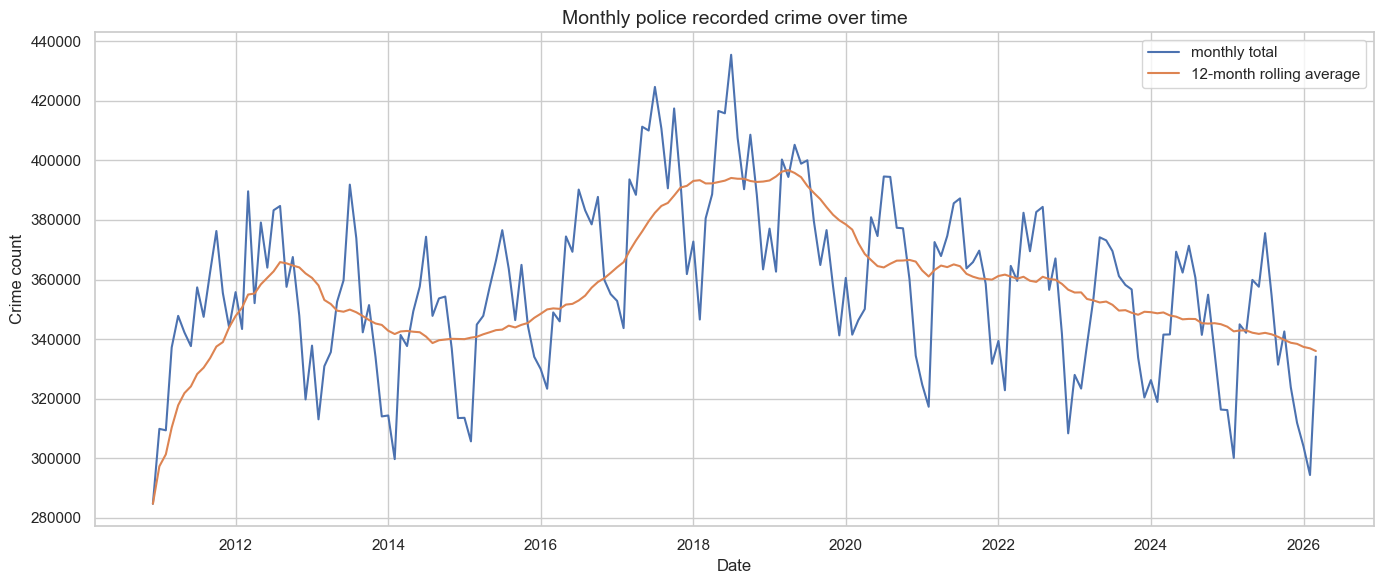

In [15]:
monthly_total = db.sql(f"""
    SELECT
        "Month" AS month,
        COUNT(*) AS total_crimes
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
    GROUP BY "Month"
    ORDER BY "Month"
""").df()

monthly_total["month"] = pd.to_datetime(monthly_total["month"], format="%Y-%m")
monthly_total["rolling_12m"] = monthly_total["total_crimes"].rolling(12, min_periods=1).mean()

save_table(monthly_total, "monthly_total_crime.csv")

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_total, x="month", y="total_crimes", label="monthly total")
sns.lineplot(data=monthly_total, x="month", y="rolling_12m", label="12-month rolling average")
plt.title("Monthly police recorded crime over time")
plt.xlabel("Date")
plt.ylabel("Crime count")
plt.tight_layout()
save_figure("monthly_police_recorded_crime_over_time.png")
plt.show()


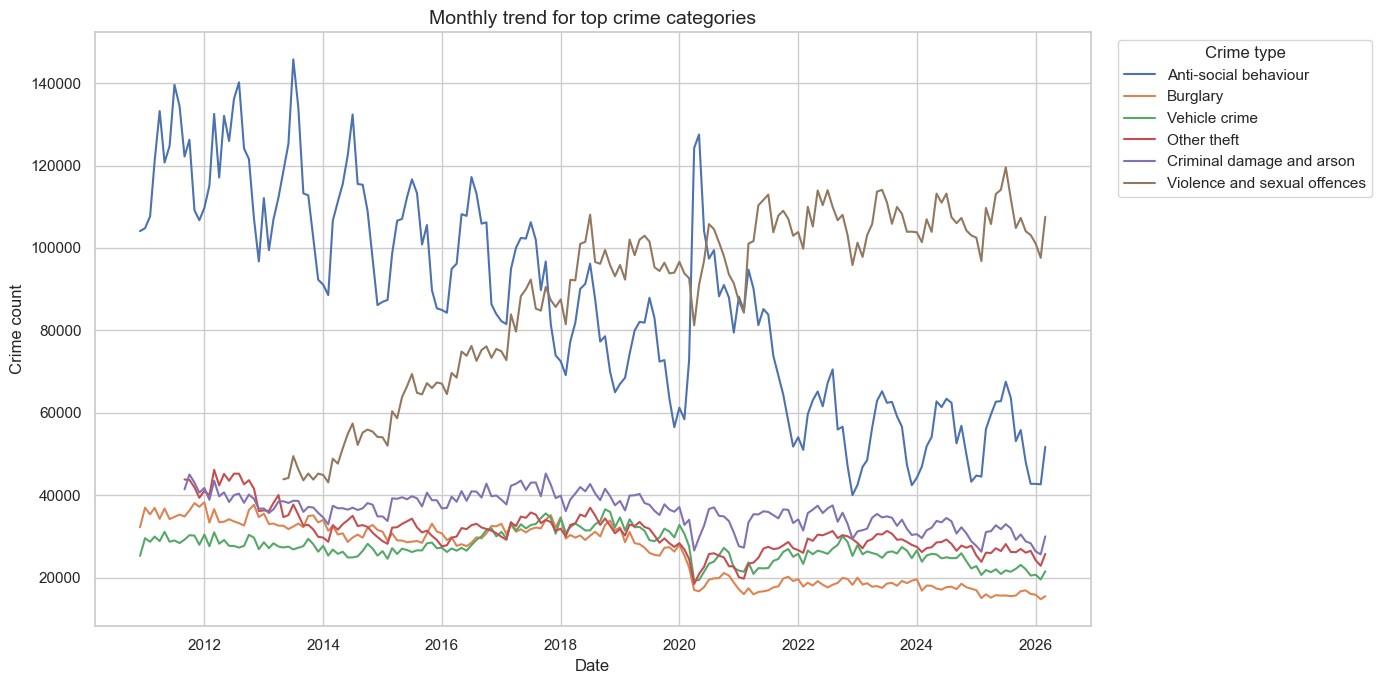

In [16]:
monthly_by_type = db.sql(f"""
    SELECT
        "Month" AS month,
        "Crime type" AS crime_type,
        COUNT(*) AS total_crimes
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
    GROUP BY "Month", "Crime type"
    ORDER BY "Month", total_crimes DESC
""").df()

monthly_by_type["month"] = pd.to_datetime(monthly_by_type["month"], format="%Y-%m")

# Top categories across the full period.
top_types = (
    monthly_by_type.groupby("crime_type", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(6)["crime_type"]
    .tolist()
)

monthly_top_types = monthly_by_type[monthly_by_type["crime_type"].isin(top_types)].copy()

save_table(monthly_by_type, "monthly_crime_by_type.csv")

plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_top_types, x="month", y="total_crimes", hue="crime_type")
plt.title("Monthly trend for top crime categories")
plt.xlabel("Date")
plt.ylabel("Crime count")
plt.legend(title="Crime type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_figure("monthly_trend_top_crime_categories.png")
plt.show()


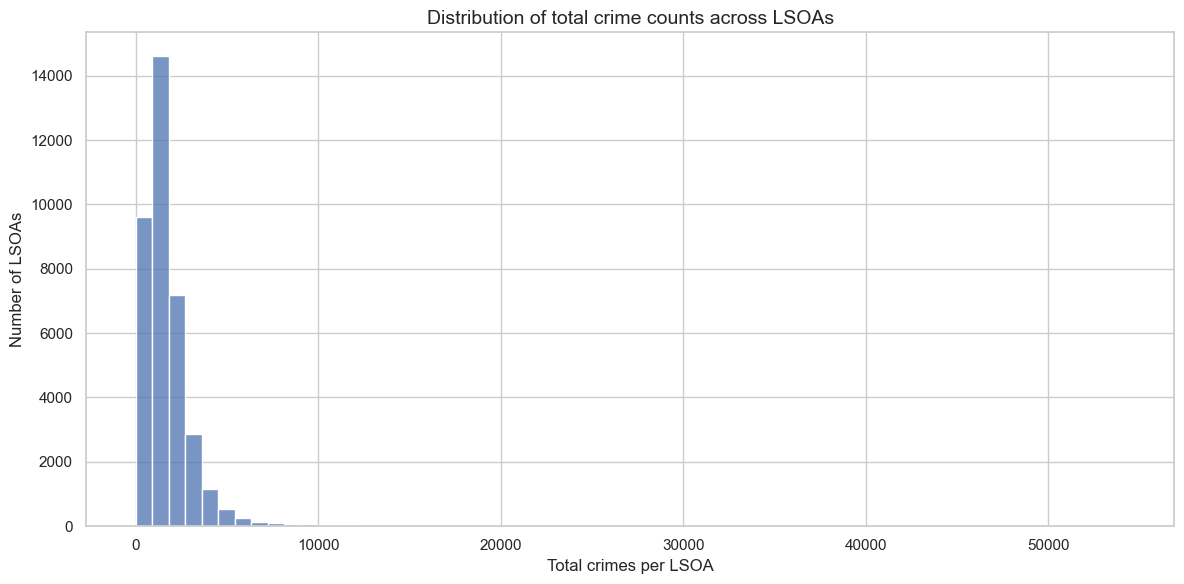

In [17]:
# Histogram: distribution of total crime counts across LSOAs
plt.figure(figsize=(12, 6))
sns.histplot(lsoa_counts["total_crimes"], bins=60)
plt.title("Distribution of total crime counts across LSOAs")
plt.xlabel("Total crimes per LSOA")
plt.ylabel("Number of LSOAs")
plt.tight_layout()
save_figure("lsoa_total_crime_distribution_histogram.png")
plt.show()


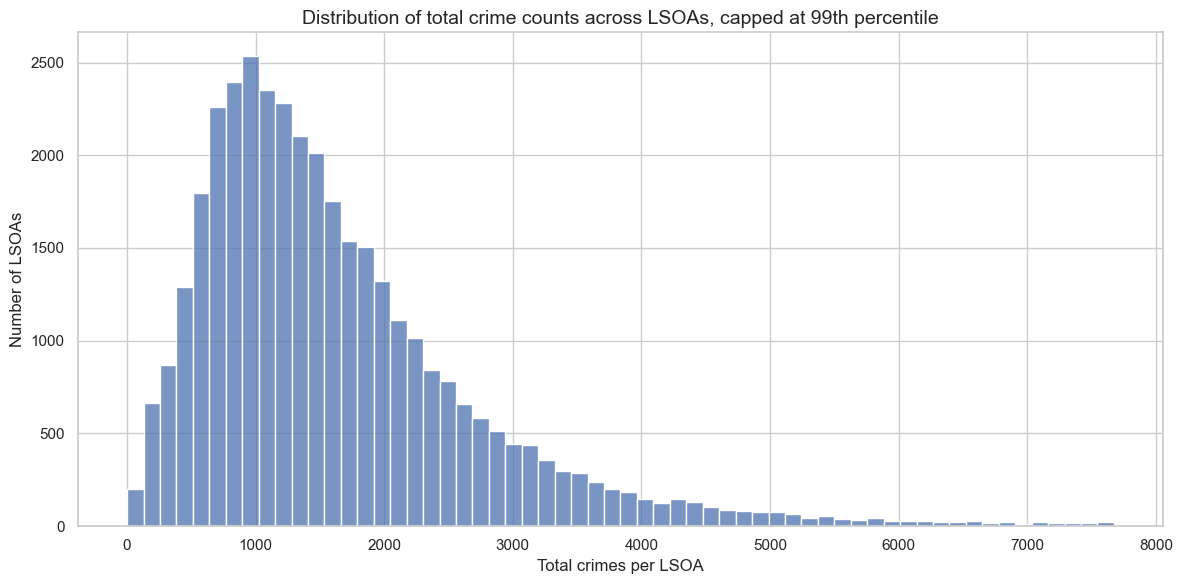

In [18]:
# Histogram with capped x-axis to improve readability of the main mass of the distribution.
x_cap = lsoa_counts["total_crimes"].quantile(0.99)

plt.figure(figsize=(12, 6))
sns.histplot(lsoa_counts[lsoa_counts["total_crimes"] <= x_cap]["total_crimes"], bins=60)
plt.title("Distribution of total crime counts across LSOAs, capped at 99th percentile")
plt.xlabel("Total crimes per LSOA")
plt.ylabel("Number of LSOAs")
plt.tight_layout()
save_figure("lsoa_total_crime_distribution_histogram_capped.png")
plt.show()


In [19]:
# Table: top X% LSOA concentration
lsoa_desc = lsoa_counts.sort_values("total_crimes", ascending=False).reset_index(drop=True).copy()
lsoa_desc["cum_crimes"] = lsoa_desc["total_crimes"].cumsum() / lsoa_desc["total_crimes"].sum()
lsoa_desc["cum_lsoas"] = (np.arange(len(lsoa_desc)) + 1) / len(lsoa_desc)

thresholds = [0.01, 0.05, 0.10, 0.20]
summary_rows = []

for threshold in thresholds:
    n = max(1, int(len(lsoa_desc) * threshold))
    share = lsoa_desc.iloc[:n]["total_crimes"].sum() / lsoa_desc["total_crimes"].sum()
    summary_rows.append({
        "top_share_lsoas": threshold,
        "crime_share": share,
    })

concentration_summary = pd.DataFrame(summary_rows)
concentration_summary["top_share_lsoas_label"] = (
    (concentration_summary["top_share_lsoas"] * 100).astype(int).astype(str) + "%"
)

save_table(concentration_summary, "lsoa_crime_concentration_summary.csv")
concentration_summary


,top_share_lsoas,crime_share,top_share_lsoas_label
0,0.01,0.070412,1%
1,0.05,0.188388,5%
2,0.10,0.289198,10%
3,0.20,0.444159,20%


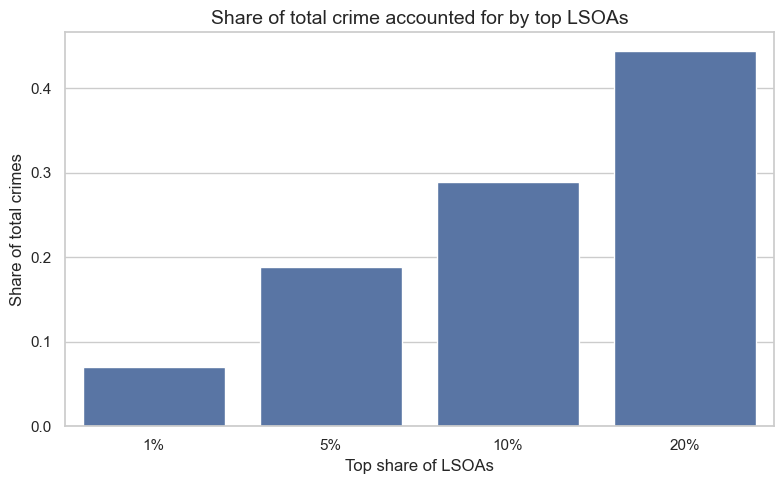

In [20]:
# Bar chart: share of total crime accounted for by top LSOAs
plt.figure(figsize=(8, 5))
sns.barplot(data=concentration_summary, x="top_share_lsoas_label", y="crime_share")
plt.title("Share of total crime accounted for by top LSOAs")
plt.xlabel("Top share of LSOAs")
plt.ylabel("Share of total crimes")
plt.tight_layout()
save_figure("top_lsoa_crime_share_bar_chart.png")
plt.show()


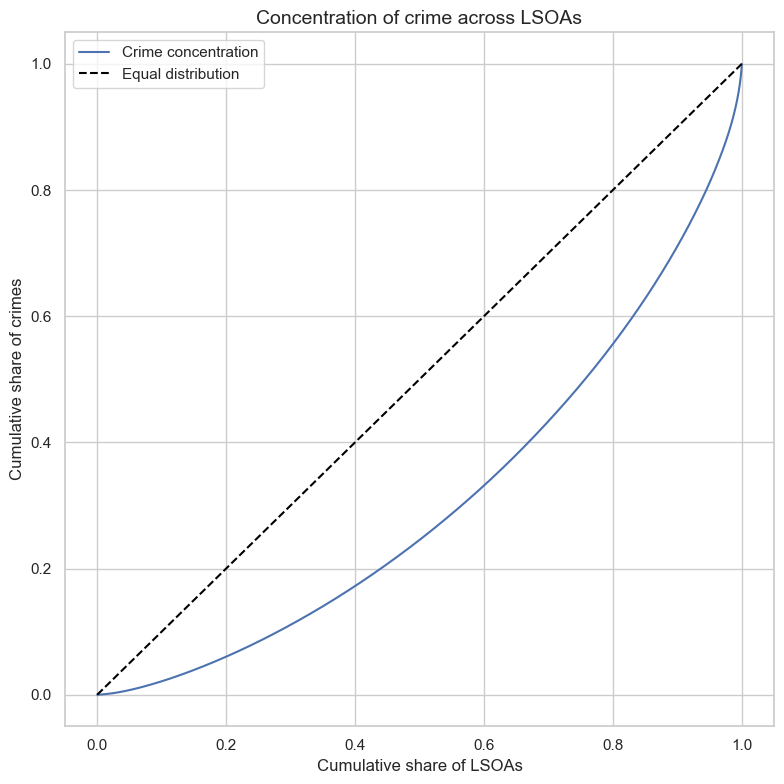

In [21]:
# Lorenz-style concentration plot
lsoa_sorted = lsoa_counts.sort_values("total_crimes").reset_index(drop=True).copy()
lsoa_sorted["cum_lsoas"] = np.arange(1, len(lsoa_sorted) + 1) / len(lsoa_sorted)
lsoa_sorted["cum_crimes"] = lsoa_sorted["total_crimes"].cumsum() / lsoa_sorted["total_crimes"].sum()

plt.figure(figsize=(8, 8))
plt.plot(lsoa_sorted["cum_lsoas"], lsoa_sorted["cum_crimes"], label="Crime concentration")
plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Equal distribution")
plt.title("Concentration of crime across LSOAs")
plt.xlabel("Cumulative share of LSOAs")
plt.ylabel("Cumulative share of crimes")
plt.legend()
plt.tight_layout()
save_figure("lsoa_lorenz_style_concentration_plot.png")
plt.show()


In [22]:
# Table: force-level total crime comparison
force_totals = db.sql(f"""
    SELECT
        "Falls within" AS police_force,
        COUNT(*) AS total_crimes
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
    GROUP BY "Falls within"
    ORDER BY total_crimes DESC
""").df()

save_table(force_totals, "force_total_crimes.csv")
force_totals.head(15)


,police_force,total_crimes
0,Metropolitan Police Service,10779828
1,West Midlands Police,3297254
2,West Yorkshire Police,3285282
3,Greater Manchester Police,2207014
4,Thames Valley Police,2019439
5,Lancashire Constabulary,2006474
6,Kent Police,1981429
7,Hampshire Constabulary,1960071
8,South Yorkshire Police,1904405
9,Essex Police,1898888


In [23]:
# Table: average crimes per LSOA within force
force_lsoa_stats = db.sql(f"""
    WITH lsoa_force_counts AS (
        SELECT
            "Falls within" AS police_force,
            "LSOA code" AS lsoa_code,
            COUNT(*) AS total_crimes
        FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
        WHERE "LSOA code" IS NOT NULL
        GROUP BY "Falls within", "LSOA code"
    )
    SELECT
        police_force,
        COUNT(*) AS n_lsoas,
        AVG(total_crimes) AS avg_crimes_per_lsoa,
        SUM(total_crimes) AS total_crimes
    FROM lsoa_force_counts
    GROUP BY police_force
    ORDER BY total_crimes DESC
""").df()

save_table(force_lsoa_stats, "force_lsoa_stats.csv")
force_lsoa_stats.head(15)


,police_force,n_lsoas,avg_crimes_per_lsoa,total_crimes
0,Metropolitan Police Service,16628,648.180118,10777939.0
1,West Midlands Police,2116,1558.203214,3297158.0
2,West Yorkshire Police,1620,2026.463580,3282871.0
3,Greater Manchester Police,1710,1290.584211,2206899.0
4,Thames Valley Police,1669,1208.629119,2017202.0
5,Lancashire Constabulary,3191,628.172987,2004500.0
6,Kent Police,2429,814.906958,1979409.0
7,Hampshire Constabulary,1908,1027.223795,1959943.0
8,South Yorkshire Police,1876,1013.962687,1902194.0
9,Essex Police,2684,706.974665,1897520.0


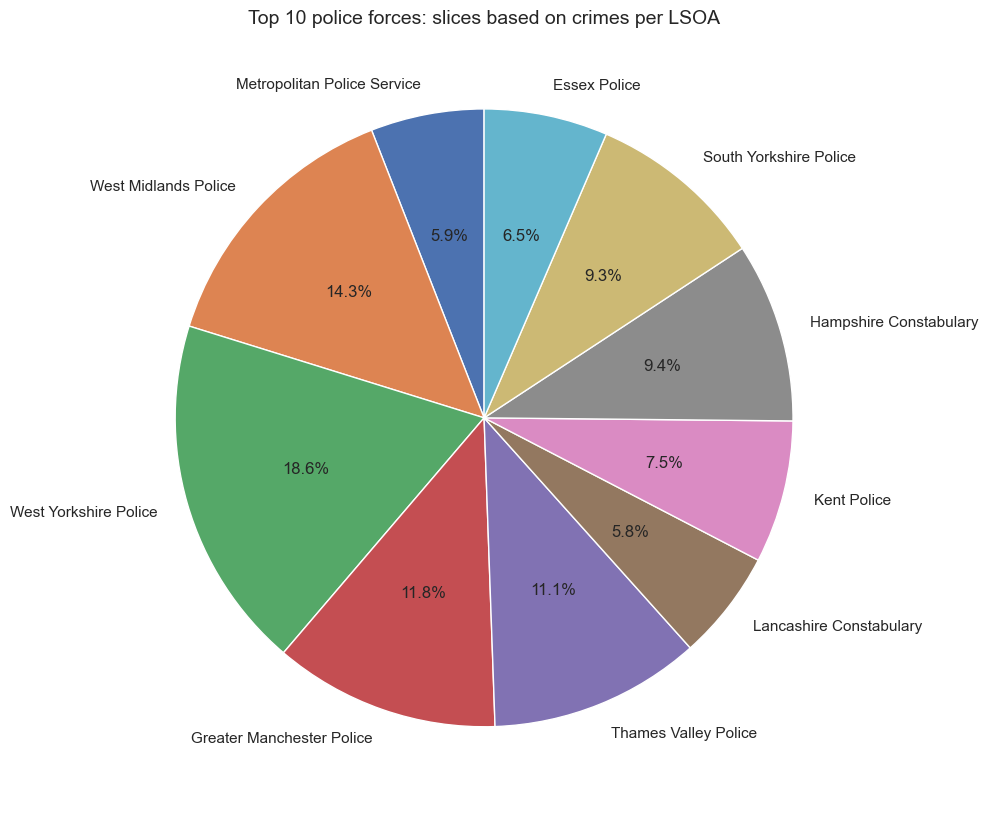

,police_force,n_lsoas,avg_crimes_per_lsoa,total_crimes,crimes_per_lsoa,normalized_share
0,Metropolitan Police Service,16628,648.180118,10777939.0,648.180118,0.059339
1,West Midlands Police,2116,1558.203214,3297158.0,1558.203214,0.142649
2,West Yorkshire Police,1620,2026.463580,3282871.0,2026.463580,0.185518
3,Greater Manchester Police,1710,1290.584211,2206899.0,1290.584211,0.118150
4,Thames Valley Police,1669,1208.629119,2017202.0,1208.629119,0.110647
5,Lancashire Constabulary,3191,628.172987,2004500.0,628.172987,0.057508
6,Kent Police,2429,814.906958,1979409.0,814.906958,0.074603
7,Hampshire Constabulary,1908,1027.223795,1959943.0,1027.223795,0.094040
8,South Yorkshire Police,1876,1013.962687,1902194.0,1013.962687,0.092826
9,Essex Police,2684,706.974665,1897520.0,706.974665,0.064722


In [24]:
# Pie chart: top 10 police forces by total crimes, slices based on crimes per LSOA.
# This is a normalisation check: large forces can dominate raw totals, so crimes per LSOA gives a different view of local burden.
top10_force_lsoa_stats = force_lsoa_stats.head(10).copy()
top10_force_lsoa_stats["crimes_per_lsoa"] = (
    top10_force_lsoa_stats["total_crimes"] / top10_force_lsoa_stats["n_lsoas"]
)
top10_force_lsoa_stats["normalized_share"] = (
    top10_force_lsoa_stats["crimes_per_lsoa"] /
    top10_force_lsoa_stats["crimes_per_lsoa"].sum()
)

plt.figure(figsize=(10, 10))
plt.pie(
    top10_force_lsoa_stats["normalized_share"],
    labels=top10_force_lsoa_stats["police_force"],
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Top 10 police forces: slices based on crimes per LSOA")
plt.tight_layout()
save_figure("top10_forces_crimes_per_lsoa_pie_chart.png")
plt.show()

top10_force_lsoa_stats


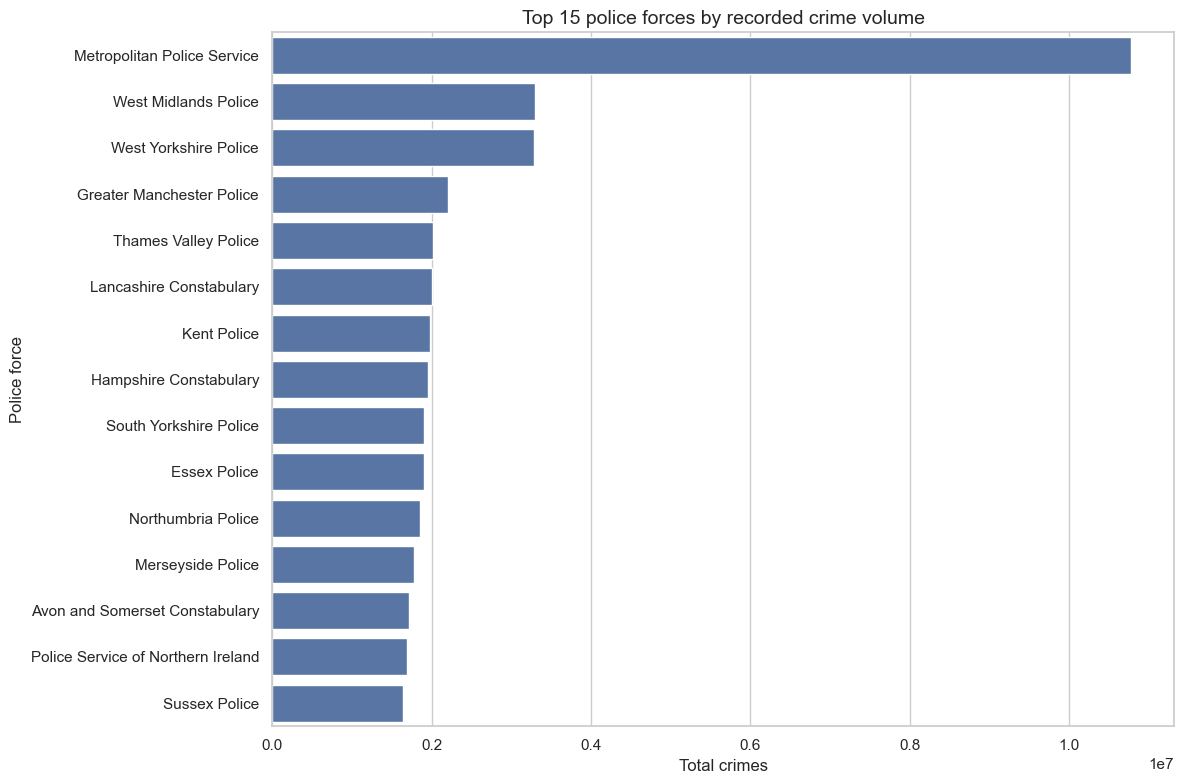

In [25]:
# Bar chart: top 15 police forces by recorded crime volume
top_forces = force_totals.head(15).copy()

plt.figure(figsize=(12, 8))
sns.barplot(data=top_forces, y="police_force", x="total_crimes", orient="h")
plt.title("Top 15 police forces by recorded crime volume")
plt.xlabel("Total crimes")
plt.ylabel("Police force")
plt.tight_layout()
save_figure("top15_police_forces_by_crime_volume.png")
plt.show()


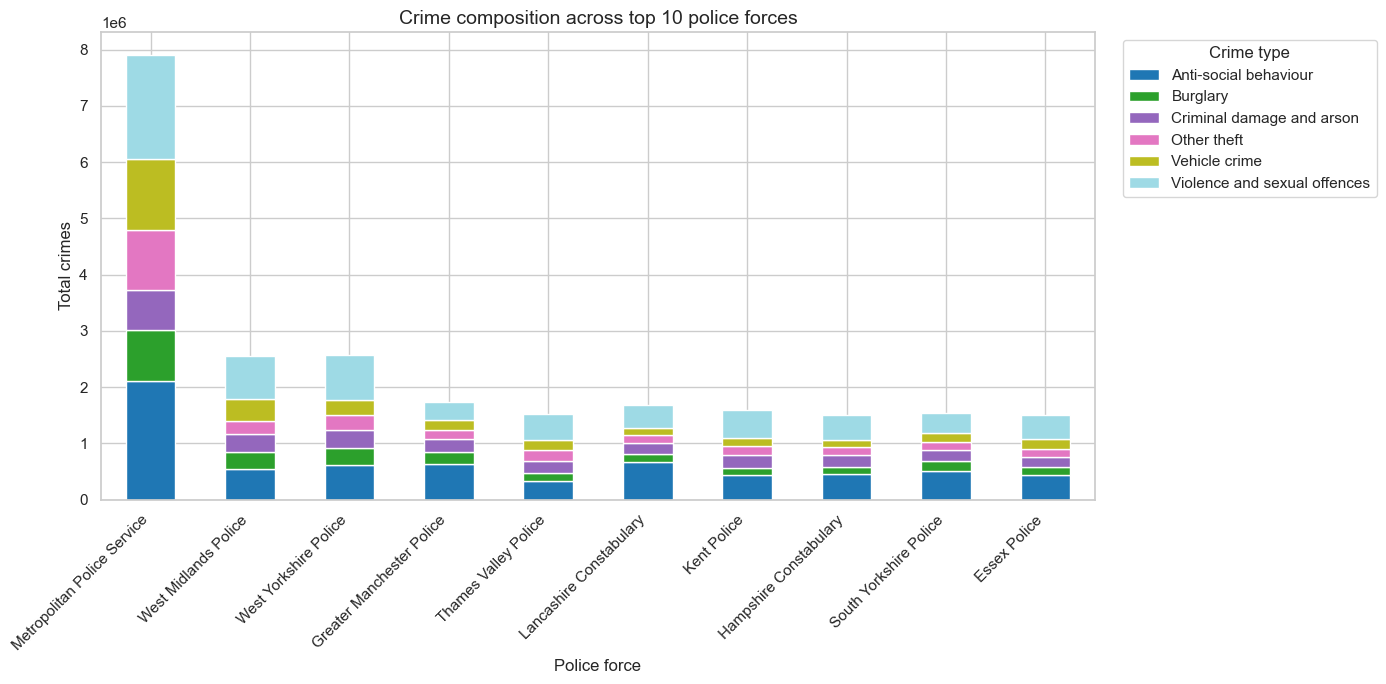

crime_type,Anti-social behaviour,Burglary,Criminal damage and arson,Other theft,Vehicle crime,Violence and sexual offences
police_force,,,,,,
Metropolitan Police Service,2109191,912445,704935,1064664,1255626,1863716
West Midlands Police,548056,303960,317648,229385,389084,766292
West Yorkshire Police,623973,291900,327408,267625,265198,787036
Greater Manchester Police,628576,223877,222522,158779,186547,309505
Thames Valley Police,334532,147359,207925,196016,179474,465069
Lancashire Constabulary,673446,134030,194731,154173,115469,414496
Kent Police,430509,129909,227957,169880,137928,491296
Hampshire Constabulary,454292,131647,199099,149530,127829,435056
South Yorkshire Police,513922,166356,198684,140684,156769,362385


In [26]:
# Stacked bar chart: crime composition across top 10 police forces
force_type = db.sql(f"""
    SELECT
        "Falls within" AS police_force,
        "Crime type" AS crime_type,
        COUNT(*) AS total_crimes
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
    GROUP BY "Falls within", "Crime type"
""").df()

top_force_names = force_totals.head(10)["police_force"].tolist()
top_type_names = (
    force_type.groupby("crime_type", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(6)["crime_type"]
    .tolist()
)

force_type_plot = force_type[
    force_type["police_force"].isin(top_force_names) &
    force_type["crime_type"].isin(top_type_names)
].copy()

pivot_force_type = force_type_plot.pivot(
    index="police_force",
    columns="crime_type",
    values="total_crimes",
).fillna(0)

pivot_force_type = pivot_force_type.loc[top_force_names]

pivot_force_type.plot(kind="bar", stacked=True, figsize=(14, 7), colormap="tab20")
plt.title("Crime composition across top 10 police forces")
plt.xlabel("Police force")
plt.ylabel("Total crimes")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Crime type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_figure("crime_composition_top10_police_forces_stacked_bar.png")
plt.show()

pivot_force_type


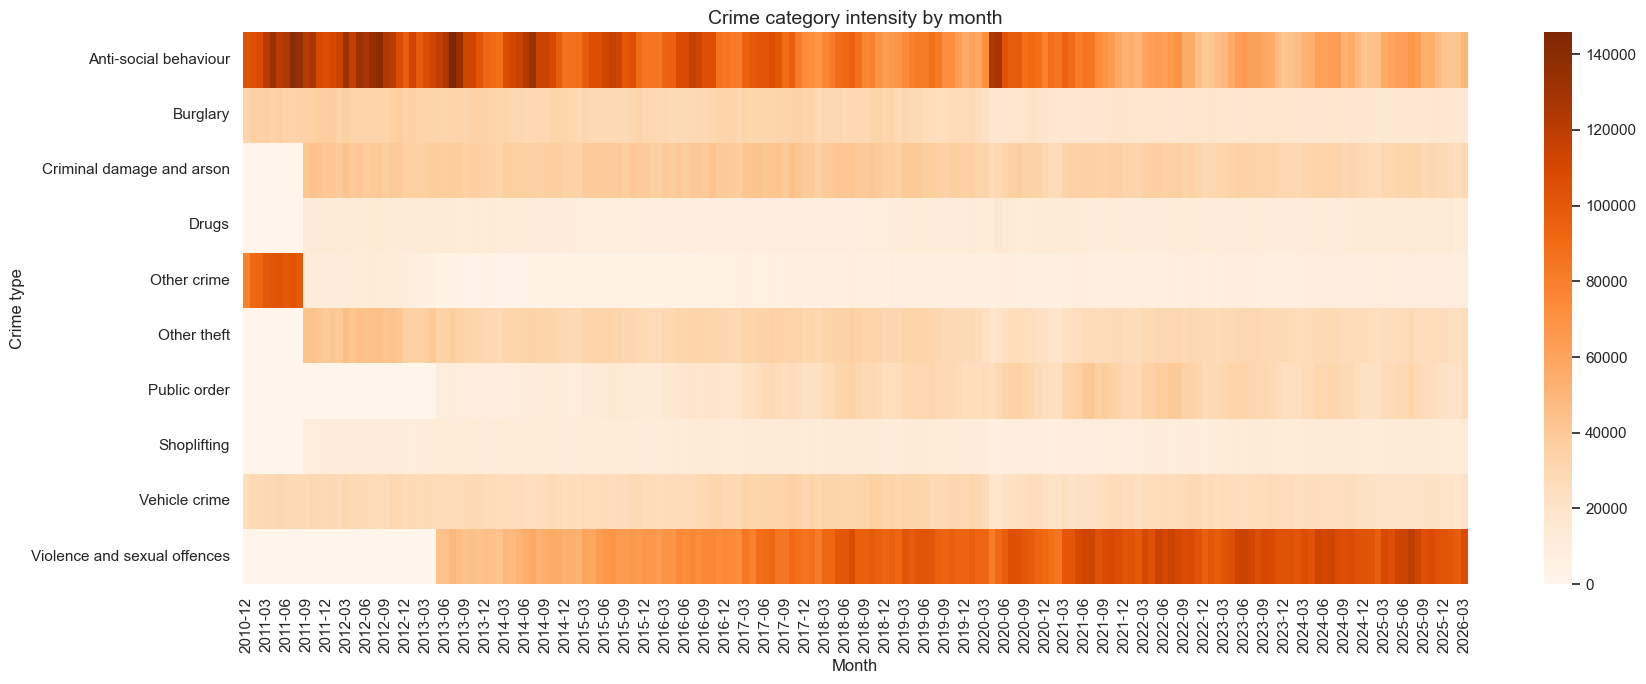

In [27]:
# Heatmap: crime category by month intensity
heatmap_df = db.sql(f"""
    SELECT
        "Month" AS month,
        "Crime type" AS crime_type,
        COUNT(*) AS total_crimes
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
    GROUP BY "Month", "Crime type"
""").df()

heatmap_df["month"] = pd.to_datetime(heatmap_df["month"], format="%Y-%m")
heatmap_df["month_str"] = heatmap_df["month"].dt.strftime("%Y-%m")

top_types_heat = (
    heatmap_df.groupby("crime_type", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(10)["crime_type"]
    .tolist()
)

heatmap_plot_df = heatmap_df[heatmap_df["crime_type"].isin(top_types_heat)].copy()
pivot_heat = heatmap_plot_df.pivot(
    index="crime_type",
    columns="month_str",
    values="total_crimes",
).fillna(0)

plt.figure(figsize=(18, 7))
sns.heatmap(pivot_heat, cmap="Oranges")
plt.title("Crime category intensity by month")
plt.xlabel("Month")
plt.ylabel("Crime type")
plt.tight_layout()
save_figure("crime_category_intensity_by_month_heatmap.png")
plt.show()


In [1]:
# Table: coverage of each crime type over time
crime_type_coverage = db.sql(f"""
    SELECT
        "Crime type" AS crime_type,
        MIN("Month") AS first_month,
        MAX("Month") AS last_month,
        COUNT(*) AS total_rows
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
    GROUP BY "Crime type"
    ORDER BY first_month, crime_type
""").df()

save_table(crime_type_coverage, "crime_type_coverage.csv")
crime_type_coverage


NameError: name 'db' is not defined

In [29]:
# Monthly crime by force
monthly_force = db.sql(f"""
    SELECT
        "Month" AS month,
        "Falls within" AS police_force,
        COUNT(*) AS total_crimes
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
    GROUP BY "Month", "Falls within"
""").df()

monthly_force["month"] = pd.to_datetime(monthly_force["month"], format="%Y-%m")
monthly_force["year"] = monthly_force["month"].dt.year
monthly_force["month_num"] = monthly_force["month"].dt.month
monthly_force["month_name"] = monthly_force["month"].dt.strftime("%b")

# Keep only complete force-years.
force_year_month_counts = (
    monthly_force.groupby(["police_force", "year"], as_index=False)["month_num"]
    .nunique()
    .rename(columns={"month_num": "n_months"})
)

complete_force_years = force_year_month_counts[
    force_year_month_counts["n_months"] == 12
][["police_force", "year"]].copy()

monthly_force_complete = monthly_force.merge(
    complete_force_years,
    on=["police_force", "year"],
    how="inner",
)

# Optional exclusions used in the exploratory work because of provider-side missing-data issues.
monthly_force_complete = monthly_force_complete[
    ~monthly_force_complete["police_force"].isin([
        "Greater Manchester Police",
        "British Transport Police",
    ])
].copy()

monthly_force_complete.head()


,month,police_force,total_crimes,year,month_num,month_name
0,2013-05-01,Gwent Police,3486,2013,5,May
1,2013-05-01,Lincolnshire Police,3877,2013,5,May
2,2013-05-01,West Midlands Police,16044,2013,5,May
3,2013-06-01,Merseyside Police,8911,2013,6,Jun
4,2015-10-01,Merseyside Police,10474,2015,10,Oct


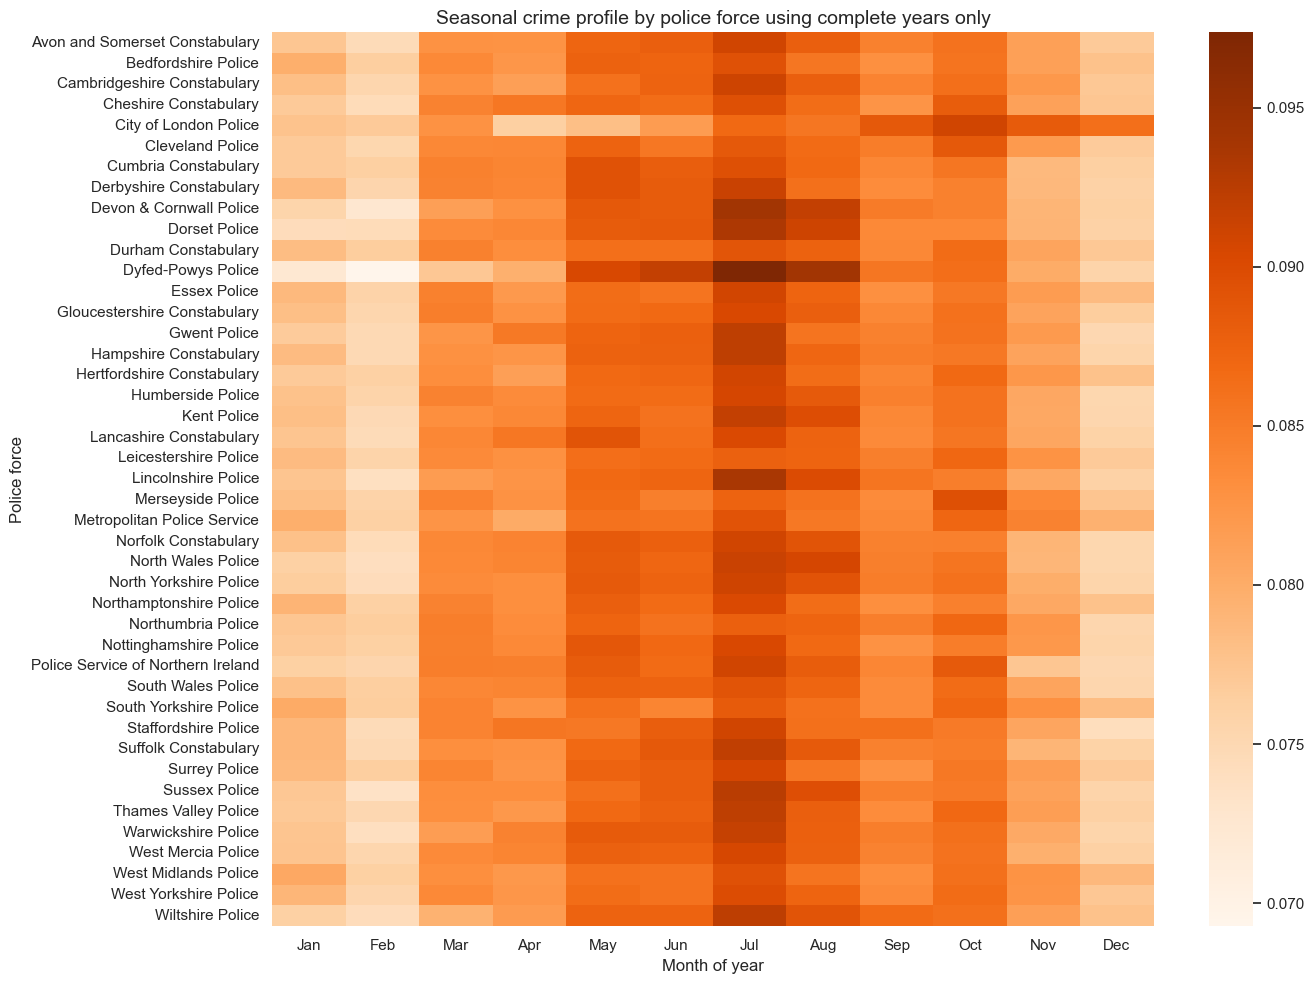

In [30]:
# Monthly share within complete force-years.
force_year_totals = (
    monthly_force_complete.groupby(["police_force", "year"], as_index=False)["total_crimes"]
    .sum()
    .rename(columns={"total_crimes": "year_total"})
)

force_year_month = monthly_force_complete.merge(
    force_year_totals,
    on=["police_force", "year"],
    how="left",
)

force_year_month["monthly_share"] = force_year_month["total_crimes"] / force_year_month["year_total"]

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

seasonal_profile_force = (
    force_year_month.groupby(["police_force", "month_num", "month_name"], as_index=False)["monthly_share"]
    .mean()
)

seasonal_profile_force["month_name"] = pd.Categorical(
    seasonal_profile_force["month_name"],
    categories=month_order,
    ordered=True,
)

pivot_seasonal_force = seasonal_profile_force.pivot(
    index="police_force",
    columns="month_name",
    values="monthly_share",
).fillna(0)

pivot_seasonal_force = pivot_seasonal_force[month_order]

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_seasonal_force, cmap="Oranges")
plt.title("Seasonal crime profile by police force using complete years only")
plt.xlabel("Month of year")
plt.ylabel("Police force")
plt.tight_layout()
save_figure("seasonal_crime_profile_by_force_complete_years.png")
plt.show()


In [31]:
# Table: summer minus winter corrected
seasonal_summary = (
    seasonal_profile_force.groupby("police_force")
    .apply(lambda g: pd.Series({
        "summer_share": g[g["month_num"].isin([6, 7, 8])]["monthly_share"].sum(),
        "winter_share": g[g["month_num"].isin([12, 1, 2])]["monthly_share"].sum(),
        "summer_minus_winter": (
            g[g["month_num"].isin([6, 7, 8])]["monthly_share"].sum()
            - g[g["month_num"].isin([12, 1, 2])]["monthly_share"].sum()
        ),
    }))
    .reset_index()
    .sort_values("summer_minus_winter", ascending=False)
)

save_table(seasonal_summary, "seasonal_summer_minus_winter_summary.csv")
seasonal_summary


,police_force,summer_share,winter_share,summer_minus_winter
11,Dyfed-Powys Police,0.283398,0.217345,0.066054
8,Devon & Cornwall Police,0.274154,0.224435,0.049719
9,Dorset Police,0.272913,0.224880,0.048033
36,Sussex Police,0.270154,0.226437,0.043717
25,North Wales Police,0.269038,0.225477,0.043561
21,Lincolnshire Police,0.270718,0.227262,0.043456
26,North Yorkshire Police,0.267648,0.226499,0.041149
38,Warwickshire Police,0.267567,0.226867,0.040700
42,Wiltshire Police,0.268771,0.228306,0.040464
24,Norfolk Constabulary,0.267729,0.227587,0.040142


In [32]:
# Table: national seasonal profile and force correlation with national seasonality.
national_month = (
    force_year_month.groupby(["year", "month_num", "month_name"], as_index=False)["total_crimes"]
    .sum()
)

national_year_total = (
    national_month.groupby("year", as_index=False)["total_crimes"]
    .sum()
    .rename(columns={"total_crimes": "year_total"})
)

national_month = national_month.merge(national_year_total, on="year", how="left")
national_month["monthly_share"] = national_month["total_crimes"] / national_month["year_total"]

national_profile = (
    national_month.groupby(["month_num", "month_name"], as_index=False)["monthly_share"]
    .mean()
)

national_vec = national_profile.sort_values("month_num")["monthly_share"].to_numpy()

force_corr_rows = []
for force, group in seasonal_profile_force.groupby("police_force"):
    vec = group.sort_values("month_num")["monthly_share"].to_numpy()
    corr = np.corrcoef(vec, national_vec)[0, 1]
    force_corr_rows.append({
        "police_force": force,
        "seasonal_corr_with_national": corr,
    })

force_corr_df = pd.DataFrame(force_corr_rows).sort_values(
    "seasonal_corr_with_national",
    ascending=False,
)

save_table(force_corr_df, "force_seasonal_correlation_with_national.csv")
force_corr_df


,police_force,seasonal_corr_with_national
0,Avon and Somerset Constabulary,0.995742
41,West Yorkshire Police,0.994934
37,Thames Valley Police,0.994718
13,Gloucestershire Constabulary,0.992741
2,Cambridgeshire Constabulary,0.990053
15,Hampshire Constabulary,0.989667
26,North Yorkshire Police,0.989456
10,Durham Constabulary,0.988227
16,Hertfordshire Constabulary,0.987225
17,Humberside Police,0.986764


In [33]:
# Table: compact seasonality summary.
n_forces = len(seasonal_summary)
n_positive = (seasonal_summary["summer_minus_winter"] > 0).sum()
median_gap = seasonal_summary["summer_minus_winter"].median()
mean_gap = seasonal_summary["summer_minus_winter"].mean()

top_gap_force = seasonal_summary.iloc[0]["police_force"]
top_gap_value = seasonal_summary.iloc[0]["summer_minus_winter"]

bottom_gap_force = seasonal_summary.iloc[-1]["police_force"]
bottom_gap_value = seasonal_summary.iloc[-1]["summer_minus_winter"]

median_corr = force_corr_df["seasonal_corr_with_national"].median()
mean_corr = force_corr_df["seasonal_corr_with_national"].mean()

lowest_corr_force = force_corr_df.iloc[-1]["police_force"]
lowest_corr_value = force_corr_df.iloc[-1]["seasonal_corr_with_national"]

summary_table = pd.DataFrame({
    "metric": [
        "forces with summer > winter",
        "median summer minus winter gap",
        "mean summer minus winter gap",
        "largest summer effect",
        "smallest summer effect",
        "median seasonal correlation",
        "mean seasonal correlation",
        "lowest seasonal correlation",
    ],
    "result": [
        f"{n_positive}/{n_forces}",
        f"{median_gap:.3f}",
        f"{mean_gap:.3f}",
        f"{top_gap_force} ({top_gap_value:.3f})",
        f"{bottom_gap_force} ({bottom_gap_value:.3f})",
        f"{median_corr:.3f}",
        f"{mean_corr:.3f}",
        f"{lowest_corr_force} ({lowest_corr_value:.3f})",
    ],
})

save_table(summary_table, "compact_seasonality_summary.csv")
summary_table


,metric,result
0,forces with summer > winter,43/43
1,median summer minus winter gap,0.036
2,mean summer minus winter gap,0.036
3,largest summer effect,Dyfed-Powys Police (0.066)
4,smallest summer effect,City of London Police (0.013)
5,median seasonal correlation,0.977
6,mean seasonal correlation,0.960
7,lowest seasonal correlation,City of London Police (0.360)


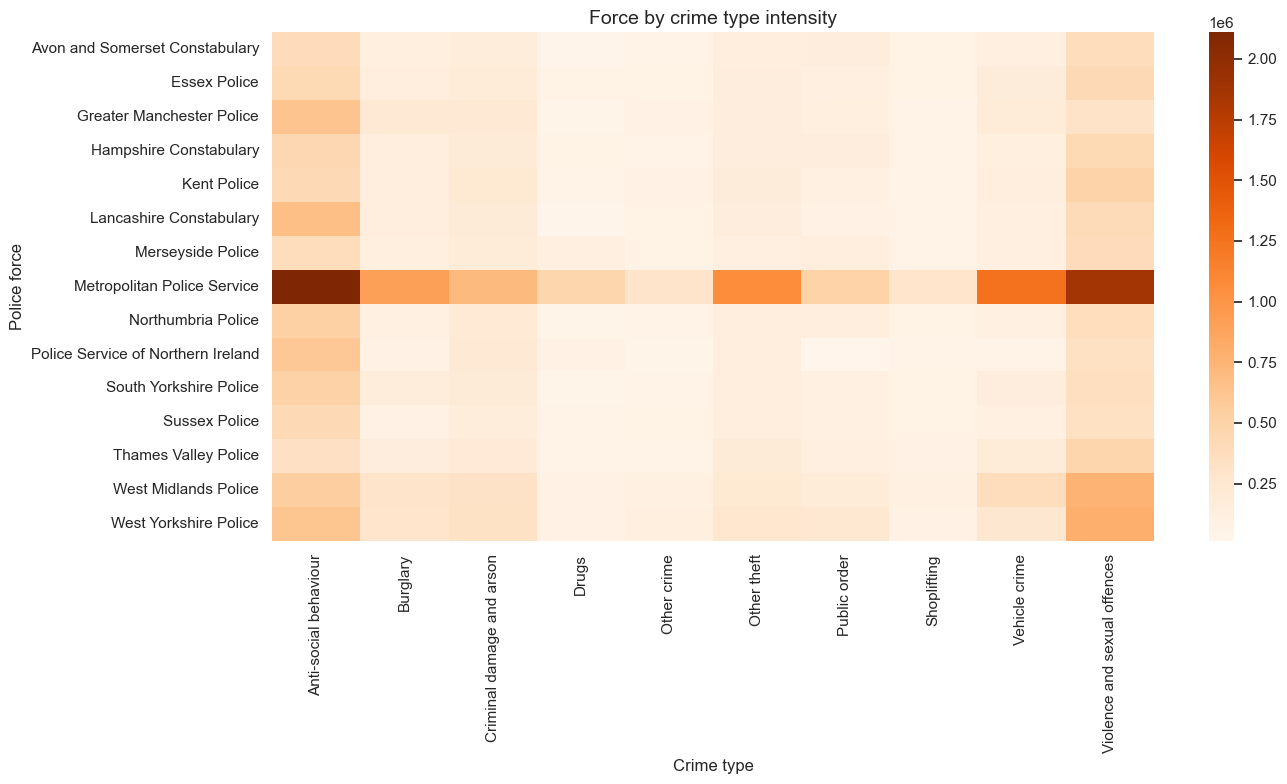

In [34]:
# Optional heatmap: force by crime type intensity for top forces/types.
force_type_heat = db.sql(f"""
    SELECT
        "Falls within" AS police_force,
        "Crime type" AS crime_type,
        COUNT(*) AS total_crimes
    FROM read_parquet('{PARQUET_SQL_PATH}') AS crimes
    GROUP BY "Falls within", "Crime type"
""").df()

top_force_heat = (
    force_type_heat.groupby("police_force", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(15)["police_force"]
    .tolist()
)

top_type_heat = (
    force_type_heat.groupby("crime_type", as_index=False)["total_crimes"]
    .sum()
    .sort_values("total_crimes", ascending=False)
    .head(10)["crime_type"]
    .tolist()
)

force_type_heat_plot = force_type_heat[
    force_type_heat["police_force"].isin(top_force_heat) &
    force_type_heat["crime_type"].isin(top_type_heat)
].copy()

pivot_force_heat = force_type_heat_plot.pivot(
    index="police_force",
    columns="crime_type",
    values="total_crimes",
).fillna(0)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_force_heat, cmap="Oranges")
plt.title("Force by crime type intensity")
plt.xlabel("Crime type")
plt.ylabel("Police force")
plt.tight_layout()
save_figure("force_by_crime_type_intensity_heatmap.png")
plt.show()
